# Modeling frequencies of the longitudinal mode

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from lazypredict.Supervised import LazyRegressor
from flaml import AutoML
from lightgbm import LGBMRegressor
import xgboost as xgb
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.linear_model import PoissonRegressor, Ridge

In [4]:
# Load dataframes from binary files
fam = '03-ext'
#base_dir = r'C:\FBr\Weiterbildung\Project'
base_dir = r'D:\Entwicklungen\share\DataScienceProject'

all_data = {}
fam_dir = os.path.join(base_dir, fam, 'data-' + fam)
all_data[fam] = {}

ft_param_path = os.path.join(base_dir, 'sep24_cds_int_us-welding', 'ft_files', str(fam) + '_feat_parameters.ft')
df_params = pd.read_feather(ft_param_path)

In [5]:
df_params.head()

,dp_no,dim_x,dim_y,dim_z,nb_slots_x,slot_x_length,slot_x_distance,nb_slots_z,slot_z_length,slot_z_distance,...,disp_long_392,disp_long_393,disp_long_394,disp_long_395,disp_long_396,disp_long_397,disp_long_398,disp_long_399,sum_sensi,coupling_long
0,13000,146.25,117.38,235.46,4,79.17,42.61,2,78.88,58.74,...,0.51,0.52,0.52,0.49,0.49,0.51,0.55,0.57,0.00,0.94
1,13001,130.53,118.96,226.27,4,82.40,54.92,2,80.52,52.99,...,0.50,0.49,0.47,0.45,0.43,0.40,0.38,0.37,0.00,0.99
2,13002,107.37,115.60,231.00,4,74.85,43.70,2,76.75,62.25,...,0.35,0.33,0.33,0.33,0.34,0.40,0.44,0.49,0.00,0.98
3,13003,116.22,123.67,257.89,4,75.32,46.25,2,79.94,65.12,...,0.37,0.32,0.31,0.31,0.33,0.36,0.43,0.47,0.00,0.99
4,13004,127.53,124.55,229.44,4,78.68,46.04,2,79.51,61.59,...,0.39,0.37,0.37,0.38,0.38,0.40,0.42,0.43,0.00,1.00


The column names of the DataFrame df_params are listed in the text file df_params_cols.txt, to get easier the column index later. The explanatory variables and the target variable are selected from the loaded dataframe:
* The explanatory variables are basically the geometrical parameters (the numbers of slots both directions are excluded, since that are representated by the encoded variables slot_2-2, ... slot_4-2)
* The target variable is the frequency of the longitudinal mode, which is one of the 100 frequencies calculated in the FEM simulation. Since the longitudinal mode is identified during the data generation, the frequency was stored in the variable "freq_long"

In [6]:
lst_param = df_params.columns.to_list()

# Benchmark of regressors

* Scaling of the explanatory variables
* Splitting of the data in train and test sets
* Runs with LazyPredict and FLAML to get a first overview of the most appropriate estimators
* Evaluation of the score (R² coefficient of determination) by cross-validation of the best estimators  

In [24]:
# Explanatory variables
lst_expl = lst_param[1:4] + lst_param[5:7] + lst_param[8:24]
# Target variable is the frequency of the longitudinal mode
target = 'freq_long'

X = df_params[lst_expl]
y = df_params[target]

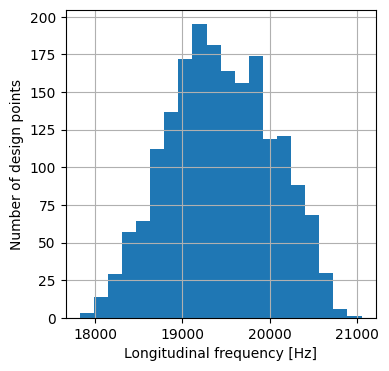

In [8]:
# Distribution of the target variable
fig, ax = plt.subplots(figsize=(4, 4))
plt.hist(y, bins=20)
plt.xlabel('Longitudinal frequency [Hz]')
plt.ylabel('Number of design points')
plt.grid(True)
plt.show()

In [26]:
# Scale all explanatory variables, except the slot class encoded columns
scaler = StandardScaler()
X = scaler.fit_transform(X[lst_expl])

Visualization of the scaled numerical variables

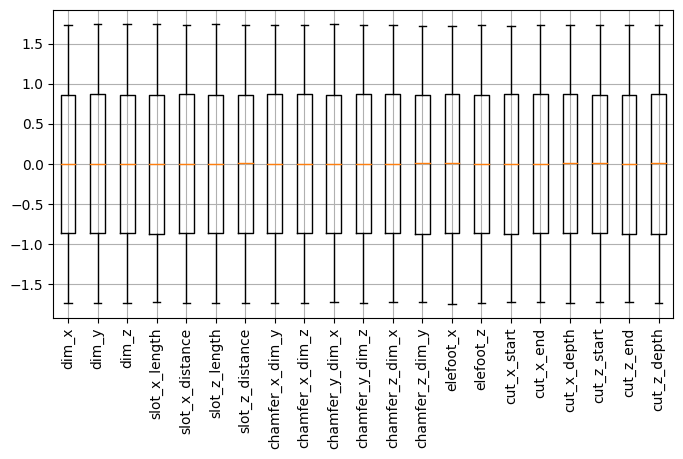

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
plt.boxplot(X, labels=lst_expl)
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

In [28]:
# New Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=55)

In [29]:
# FLAML finds the best estimators in the given time bugdet (here 10 minutes) 
automl = AutoML()
automl_settings = {
    'task': 'regression',
     'metric': 'r2',
     'time_budget': 300,
     'n_splits': 5,
     'log_file_name': 'automl-frequencies.log'
     }
automl.fit(X_train, y_train, **automl_settings)

print ('The best estimator found my FLAML:', automl.best_estimator)
print('Best config:', automl.best_config_per_estimator[automl.best_estimator])

y_pred = automl.predict(X_test)
print('r2 score:', r2_score(y_test, y_pred))

[flaml.automl.logger: 08-26 16:05:23] {1728} INFO - task = regression
[flaml.automl.logger: 08-26 16:05:23] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 08-26 16:05:23] {1838} INFO - Minimizing error metric: 1-r2


[flaml.automl.logger: 08-26 16:05:23] {1955} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd']
[flaml.automl.logger: 08-26 16:05:23] {2258} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 08-26 16:05:24] {2393} INFO - Estimated sufficient time budget=568s. Estimated necessary time budget=4s.
[flaml.automl.logger: 08-26 16:05:24] {2442} INFO -  at 0.1s,	estimator lgbm's best error=0.6129,	best estimator lgbm's best error=0.6129
[flaml.automl.logger: 08-26 16:05:24] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 08-26 16:05:24] {2442} INFO -  at 0.1s,	estimator lgbm's best error=0.6129,	best estimator lgbm's best error=0.6129
[flaml.automl.logger: 08-26 16:05:24] {2258} INFO - iteration 2, current learner lgbm
[flaml.automl.logger: 08-26 16:05:24] {2442} INFO -  at 0.2s,	estimator lgbm's best error=0.3179,	best estimator lgbm's best error=0.3179
[flaml.automl.logger: 08-26 16:05:24] {2258} INFO